# Consensus Sequences

Generate consensus sequences from multiple sequence alignments of all unique haplotypes within a given transcript.

Dependencies:
- `conda-forge::biopython`
- `bioconda::clustalo`
- `bioconda::pymsaviz`

Sources:
- https://help.geneious.com/hc/en-us/articles/360044627712-Which-multiple-alignment-algorithm-should-I-use
- https://biopython.org/docs/1.74/api/Bio.Align.Applications.html
- BiopythonDeprecationWarning: The `dumb_consensus` method is deprecated and will be removed in a future release of Biopython. As an alternative, you can convert the multiple sequence alignment object to a new-style Alignment object by via its `.alignment` property, and then create a Motif object. You can then use the `.consensus` or `.degenerate_consensus` property of the Motif object to get a consensus sequence. For more control over how the consensus sequence is calculated, you can call the `calculate_consensus` method on the `.counts` property of the Motif object. This is an example for a multiple sequence alignment `msa` of DNA nucleotides:


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.ensembl_rest as er
import src.biopython as bp

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


List the trancripts IDs you want to generate consensus sequences for.

Here, we're just going to focus on the transcripts with IDs we can map onto the ProteinGym dataset.

In [2]:
protein_df = pg.merge_resources()
tx_ids = utils.intersect(protein_df['ENST'].tolist(), 
                         hs.list_haplotypes()
                         )
print(len(tx_ids))

ProteinGym: Gathering resources:   0%|          | 0/2 [00:00<?, ?it/s]

Found haplotypes of 47325 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes'
2499


Generate the FASTA files for each transcript and align them using ClustalOmega.

In [3]:
import src.Align.align_utils as au

alignment_paths = au.align_haplotypes(tx_ids, error=False)

Aligning protein_haplotypes:   0%|          | 0/2499 [00:00<?, ?it/s]

Compute consensus sequences from the aligned FASTA files.

In [7]:
%%capture

consensus_df = au.get_consensus_sequences(alignment_paths, 
                                          weighted=False)
consensus_df.head()

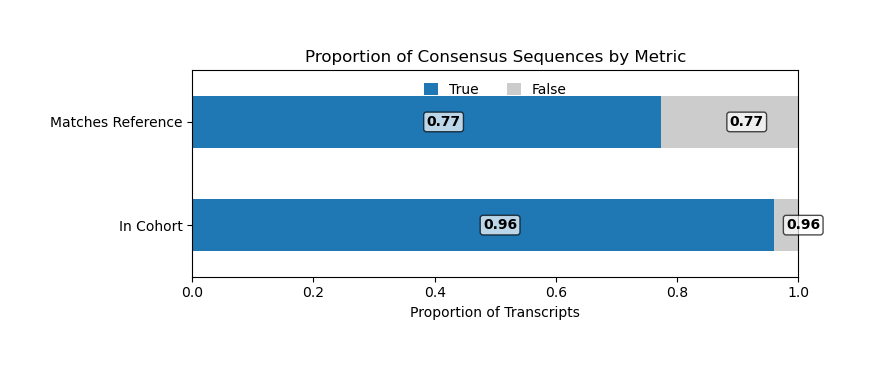

In cohort proportions:
in_cohort
True     0.9593
False    0.0407
Name: proportion, dtype: float64

Matches reference proportions:
is_ref
True     0.772894
False    0.227106
Name: proportion, dtype: float64


In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(8, 3))

# Prepare data for horizontal bar chart
metrics = ['In Cohort', 'Matches Reference']
true_values = [consensus_df['in_cohort'].mean(), consensus_df['is_ref'].mean()]
false_values = [1 - v for v in true_values]

# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({
    'True': true_values,
    'False': false_values
}, index=metrics)

# Plot horizontal stacked bar chart with blue for True and grey for False
plot_data.plot(kind='barh', stacked=True, ax=ax, color=['#1f77b4', '#cccccc'])
ax.set_title('Consensus Sequence Metrics')
ax.set_xlabel('Proportion of Transcripts')
ax.set_xlim(0, 1)

# Place legend below the plot
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=2)

# Add text labels for the True proportions
for i, v in enumerate(true_values):
    ax.text(v/2, i, f'{v:.2f}', va='center', color='black', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.2'))
    
# Add text labels for the False proportions
for i, v in enumerate(false_values):
    ax.text(1-v/2, i, f'{1-v:.2f}', va='center', color='black', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.2'))

plt.tight_layout()
plt.show()

# Print the actual values for reference
print("In cohort proportions:")
in_cohort_counts = consensus_df['in_cohort'].value_counts(normalize=True)
print(in_cohort_counts)
print("\nMatches reference proportions:")
is_ref_counts = consensus_df['is_ref'].value_counts(normalize=True)
print(is_ref_counts)

MLFEGLDLVSALATLAACLVSVTLLLAVSQQLWQLRWAATRDKSCKLPIPKGSMGFPLIGETGHWLLQGSGFQSSRREKYGNVFKTHLLGRPLIRVTGAENVRKILMGEHHLVSTEWPRSTRMLLGPNTVSNSIGDIHRNKRKVFSKIFSHEALESYLPKIQLVIQDTLRAWSSHPEAINVYQEAQKLTFRMAIRVLLGFSIPEEDLGHLFEVYQQFVDNVFSLPVDLPFSGYRRGIQARQILQKGLEKAIREKLQCTQGKDYLDALDLLIESSKEHGKEMTMQELKDGTLELIFAAYATTASASTSLIMQLLKHPTVLEKLRDELRAHGILHSGGCPCEGTLRLDTLSGLRYLDCVIKEVMRLFTPISGGYRTVLQTFELDGFQIPKGWSVMYSIRDTHDTAPVFKDVNVFDPDRFSQARSEDKDGRFHYLPFGGGVRTCLGKHLAKLFLKVLAVELASTSRFELATRTFPRITLVPVLHPVDGLSVKFFGLDSNQNEILPETEAMLSATV


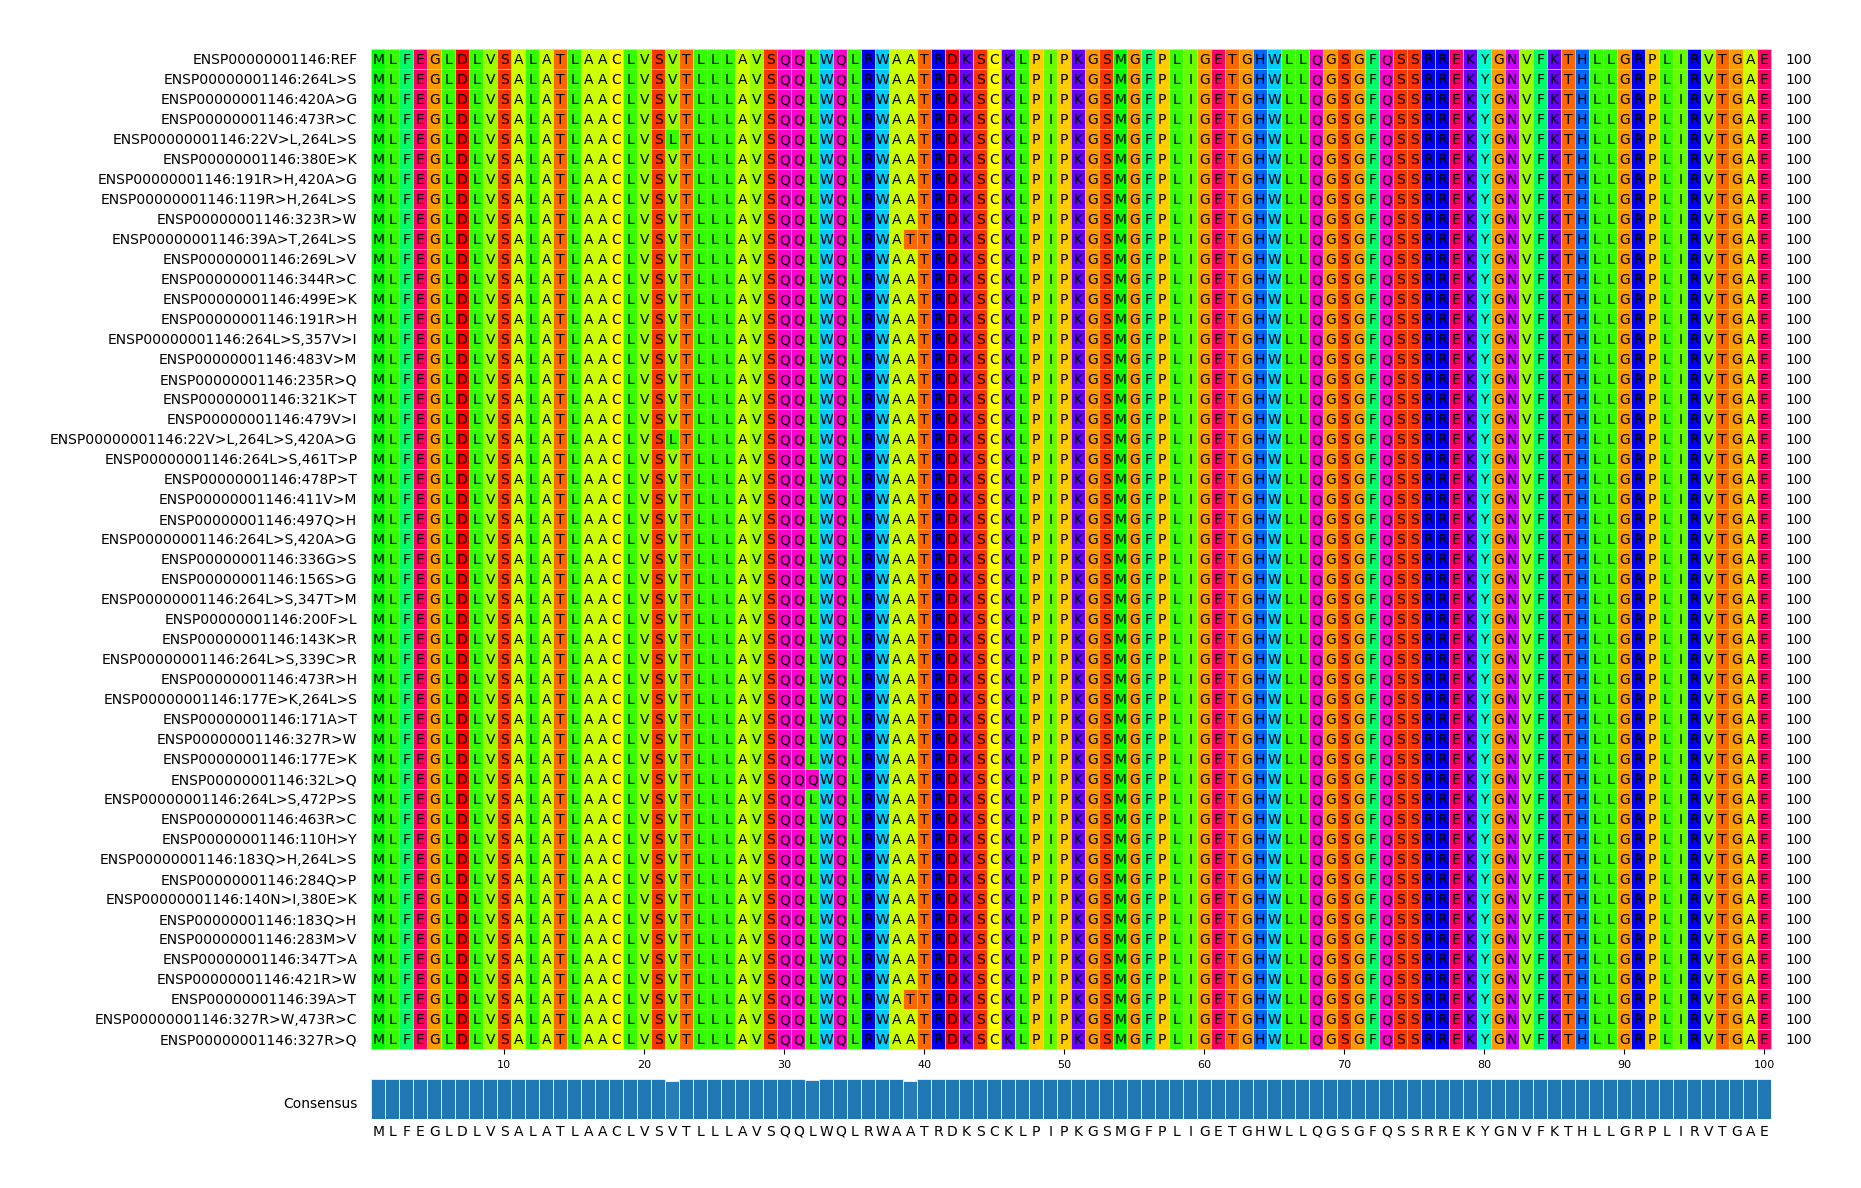

In [12]:
# Get the first transcript ID and its alignment path for demonstration
first_tx_id = list(alignment_paths.keys())[0]
first_alignment_path = alignment_paths[first_tx_id]

# Plot the MSA and consensus for the first transcript
mv, fig = au.plot_msa_with_consensus(first_alignment_path, end=100)

print(mv.consensus_seq)
